# Cell GLM model



In [545]:
# Imports
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import holoviews as hv
from holoviews import opts
import hvplot.pandas
hv.extension('bokeh')

from pprint import pprint

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

# Import the class
import importlib
import session_class
import cell_analysis
importlib.reload(session_class)
importlib.reload(cell_analysis)
from session_class import Session
from matplotlib import pyplot as plt

# Also reload multi_session_pca if needed
import multi_session_pca
importlib.reload(multi_session_pca)
from multi_session_pca import MultiSessionPCA

print("✓ Imports loaded successfully!")

✓ Imports loaded successfully!


## 1. Load cell via session

In [546]:
# Load MSN cell database
monkey = 'fiona'  # 'yasmin' or 'fiona'

base_path = Path.cwd().parent / 'data' / 'unified_cell_trial_data' 
pickle_file = base_path / f'msn_{monkey}_cell_trial_data.pkl'

cell_df = pd.read_pickle(pickle_file)

In [547]:
# Add parent directory to path to import Cell and PopulationAnalyzer
sys.path.insert(0, str(Path.cwd().parent))
import importlib
import session_class
import cell_analysis
import pca_helpers
importlib.reload(session_class)
importlib.reload(cell_analysis)
importlib.reload(pca_helpers)
from session_class import Session
from pca_helpers import extract_session_psth_worker
from cell_analysis import Cell, PopulationAnalyzer

print("Cell, PopulationAnalyzer, and Session classes imported successfully!")

Cell, PopulationAnalyzer, and Session classes imported successfully!


In [548]:
# Select a session to analyze - use session with most cells
session_cell_counts = cell_df.groupby('trial_session')['cell_ID'].nunique().sort_values(ascending=False)
# best_session_id = session_cell_counts.index[0] 
best_session_id = "fi211115a" 

print(f"Using session with most cells: {best_session_id}")
print(f"Number of cells in this session: {session_cell_counts.iloc[0]}")

# Get all data for this session
session_data = cell_df[cell_df['trial_session'] == best_session_id]

# Create Session object
session = Session(session_data, verbose=True)

Using session with most cells: fi211115a
Number of cells in this session: 85
Session fi211115a initialized:
  - Number of cells: 53
  - Total trials: 960
  - Trial types: ['CONT', 'GO', 'STOP']
  - Directions: [np.int64(0), np.int64(180)]


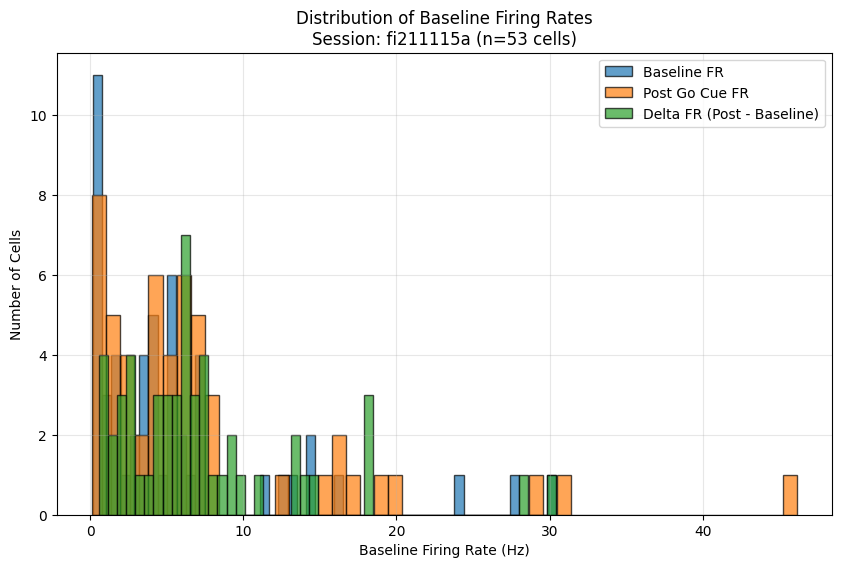

Mean baseline FR: 5.78 Hz
Median baseline FR: 4.20 Hz
Range: 0.18 - 30.46 Hz


In [549]:
# Calculate baseline firing rate for each cell in the session
baseline_frs = []
post_frs = []
delta_frs = []

for cell_id in session.cell_ids:
    cell = session.get_cell(cell_id)
    
    # Calculate baseline FR for this cell
    # Baseline: -100 to 0 ms relative to go_cue
    baseline_window = (-500, 0)
    baseline_counts = []
    post_counts = []
    delta_counts = []
    
    # Use successful trials only
    successful_trials = cell.data[cell.data['trial_failed'] == False]
    
    for _, trial in successful_trials.iterrows():
        go_time = trial['go_cue']
        spikes = np.array(trial['neural_data'])
        
        # Count spikes in baseline window
        baseline_start = go_time + baseline_window[0]
        baseline_end = go_time + baseline_window[1]
        
        spike_count = np.sum((spikes >= baseline_start) & (spikes < baseline_end))
        spike_count_post = np.sum(
            (spikes >= go_time) & 
            (spikes < go_time + 250)
        )
        baseline_counts.append(spike_count)
        post_counts.append(spike_count_post)
        delta_counts.append(np.abs(spike_count_post - spike_count))
    
    # Calculate mean baseline FR in Hz
    window_duration = (baseline_window[1] - baseline_window[0]) / 1000  # in seconds
    mean_baseline_fr = np.mean(baseline_counts) / window_duration
    mean_post_fr = np.mean(post_counts) / 0.25  # 100 ms window after go cue
    delta_fr = np.mean(delta_counts) / 0.25  # 100 ms window after go cue
    baseline_frs.append(mean_baseline_fr)
    post_frs.append(mean_post_fr)
    delta_frs.append(delta_fr)


# Plot distribution
plt.figure(figsize=(10, 6))
plt.hist(baseline_frs, bins=50, edgecolor='black', alpha=0.7, label='Baseline FR')
plt.hist(post_frs, bins=50, edgecolor='black', alpha=0.7, label='Post Go Cue FR')
plt.hist(delta_frs, bins=50, edgecolor='black', alpha=0.7, label='Delta FR (Post - Baseline)')
plt.xlabel('Baseline Firing Rate (Hz)')
plt.ylabel('Number of Cells')
plt.title(f'Distribution of Baseline Firing Rates\nSession: {session.session_id} (n={len(baseline_frs)} cells)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"Mean baseline FR: {np.mean(baseline_frs):.2f} Hz")
print(f"Median baseline FR: {np.median(baseline_frs):.2f} Hz")
print(f"Range: {np.min(baseline_frs):.2f} - {np.max(baseline_frs):.2f} Hz")

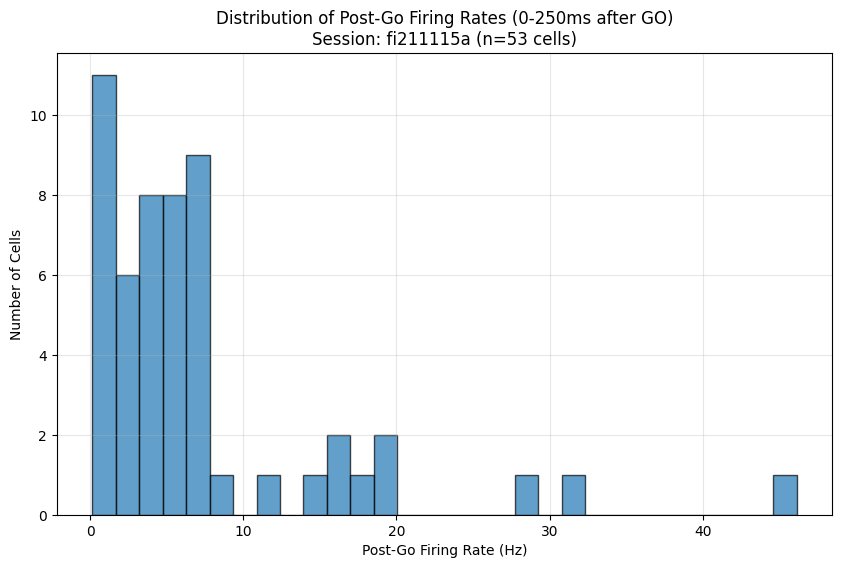

Mean post-go FR: 7.39 Hz
Median post-go FR: 5.02 Hz
Range: 0.14 - 46.14 Hz


In [550]:
# Calculate post-go firing rate for each cell in the session
post_go_frs = []
post_go_win_len = 250

for cell_id in session.cell_ids:
    cell = session.get_cell(cell_id)
    
    # Post-go window: 0 to post_go_win_len ms after go_cue
    post_go_window = (0, post_go_win_len)
    post_go_counts = []
    
    # Use successful trials only
    successful_trials = cell.data[cell.data['trial_failed'] == False]
    
    for _, trial in successful_trials.iterrows():
        go_time = trial['go_cue']
        spikes = np.array(trial['neural_data'])
        
        # Count spikes in post-go window
        post_go_start = go_time + post_go_window[0]
        post_go_end = go_time + post_go_window[1]
        
        spike_count = np.sum((spikes >= post_go_start) & (spikes < post_go_end))
        post_go_counts.append(spike_count)
    
    # Calculate mean post-go FR in Hz
    window_duration = (post_go_window[1] - post_go_window[0]) / 1000  # in seconds
    mean_post_go_fr = np.mean(post_go_counts) / window_duration
    post_go_frs.append(mean_post_go_fr)

# Plot distribution
plt.figure(figsize=(10, 6))
plt.hist(post_go_frs, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Post-Go Firing Rate (Hz)')
plt.ylabel('Number of Cells')
plt.title(f'Distribution of Post-Go Firing Rates (0-{post_go_win_len}ms after GO)\nSession: {session.session_id} (n={len(post_go_frs)} cells)')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Mean post-go FR: {np.mean(post_go_frs):.2f} Hz")
print(f"Median post-go FR: {np.median(post_go_frs):.2f} Hz")
print(f"Range: {np.min(post_go_frs):.2f} - {np.max(post_go_frs):.2f} Hz")

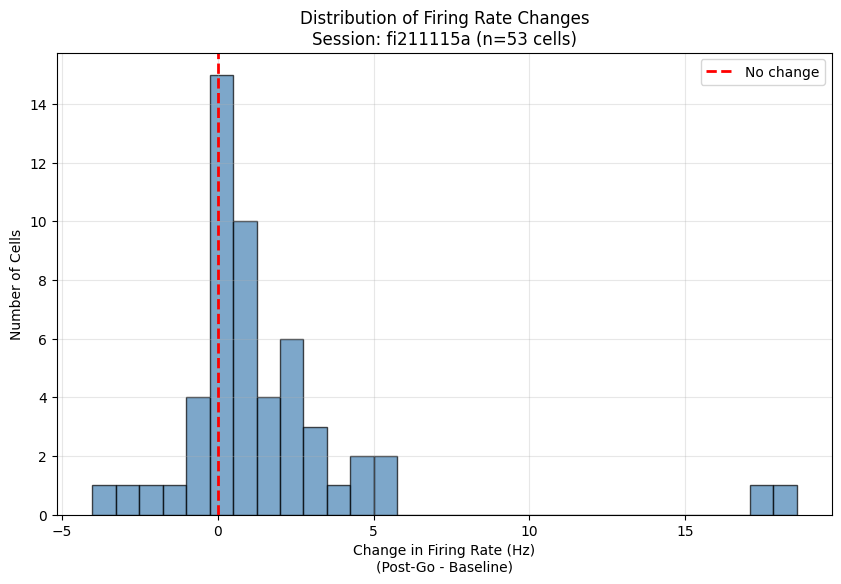

Mean change: 1.61 Hz
Median change: 0.69 Hz
Std deviation: 3.76 Hz
Range: -4.03 to 18.59 Hz

Cells with increased activity: 37 (69.8%)
Cells with decreased activity: 16 (30.2%)
Cells with no change: 0


In [551]:
# Calculate the change in firing rate (post-go - baseline)
fr_changes = np.array(post_go_frs) - np.array(baseline_frs)

# Plot distribution
plt.figure(figsize=(10, 6))
plt.hist(fr_changes, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No change')
plt.xlabel('Change in Firing Rate (Hz)\n(Post-Go - Baseline)')
plt.ylabel('Number of Cells')
plt.title(f'Distribution of Firing Rate Changes\nSession: {session.session_id} (n={len(fr_changes)} cells)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Mean change: {np.mean(fr_changes):.2f} Hz")
print(f"Median change: {np.median(fr_changes):.2f} Hz")
print(f"Std deviation: {np.std(fr_changes):.2f} Hz")
print(f"Range: {np.min(fr_changes):.2f} to {np.max(fr_changes):.2f} Hz")
print(f"\nCells with increased activity: {np.sum(fr_changes > 0)} ({100*np.sum(fr_changes > 0)/len(fr_changes):.1f}%)")
print(f"Cells with decreased activity: {np.sum(fr_changes < 0)} ({100*np.sum(fr_changes < 0)/len(fr_changes):.1f}%)")
print(f"Cells with no change: {np.sum(fr_changes == 0)}")

In [552]:
session.drop_cells_with_missing_trial_type_or_dir_data()
session

Session fi211115a | Cells: 53 | Trials: 960 | Trial Types: ['CONT', 'GO', 'STOP'] | Directions: [np.int64(0), np.int64(180)]

In [553]:
# hv.help(hv.Curve)

In [554]:
cell = session.get_cell(session.cell_ids[0])
print(f"Loaded cell ID: {cell.cell_id} from session: {session.session_id}")
cell

Loaded cell ID: 2341 from session: fi211115a


Cell 2341 | Type: msn | Trials: 960 | Directions: [np.int64(0), np.int64(180)] | Trial Types: ['CONT', 'GO', 'STOP'] | SSDs: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]

Loading BokehJS ...

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
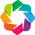

Randomly selected cell: Cell 2377 | Type: msn | Trials: 960 | Directions: [np.int64(0), np.int64(180)] | Trial Types: ['CONT', 'GO', 'STOP'] | SSDs: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
260
46
97


In [555]:
from bokeh.io import output_notebook

output_notebook()
hv.extension('bokeh')

random_cell_id = np.random.choice(session.cell_ids)
# random_cell_id = 2366
random_cell = session.get_cell(random_cell_id)
print(f"Randomly selected cell: {random_cell}")
random_cell.plot_psth_by_type_direction()

plot = random_cell.plot_psth_by_type_direction(
    bin_size=1, separate_ssd=False,
    alignment_point='go_cue',
    # alignment_point='stop_cue',
    epok=[-200, 500], smooth_ker_size=19
)
# (
#     plot[0]['GO'] * plot[180]['GO'] + \
#     plot[0]['STOP'] * plot[180]['STOP'] + \
#     plot[0]['CONT'] * plot[180]['CONT']
# ).cols(1)
overlay = (
    plot[180]['GO'].opts(opts.Curve(color="red")) * \
    plot[180]['STOP'].opts(opts.Curve(color="green")) * \
    plot[180]['CONT'].opts(opts.Curve(color="blue"))
)


for i in range(1,4):   
    print(eval(f"overlay.Curve.{'I'*i}.opts['title'].split('- ')[1].split(' ')[0]"))
  


In [556]:
# random_cell_id = np.random.choice(session.cell_ids)
# random_cell = session.get_cell(random_cell_id)
print(f"Randomly selected cell: {random_cell}")
random_cell.plot_raster(
    alignment_point='go_cue',
    # alignment_point='stop_cue',
    epok=[-100, 200],
    # color_by='ssd',  # Color by SSD number
    color_by='direction',
    direction=180,
    trial_type='GO',
    # success_only=True
)


Randomly selected cell: Cell 2377 | Type: msn | Trials: 960 | Directions: [np.int64(0), np.int64(180)] | Trial Types: ['CONT', 'GO', 'STOP'] | SSDs: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]


:Overlay
   .Curve.I   :Curve   [x]   (y)
   .HeatMap.I :HeatMap   [columns,index]   (value)

## 2. Fit GLM model to cell data

In [557]:
import statsmodels.api as sm
from statsmodels.genmod.families import Poisson

class CellGLM(Cell):
    """
    Extended Cell class with GLM functionality to predict firing rate 
    based on trial conditions (Baseline, GO, STOP, CONT).
    """
    def __init__(self, cell_df, verbose=False):
        super().__init__(cell_df, verbose)
        self.glm_results = None
        self.n_bins = None
        self.bin_size = None
        self.feature_names = []

    def fit_glm(self, n_bins=10, bin_size=10):
        """
        Fit a Poisson GLM to the cell's spiking activity.
        Only uses successful trials.
        
        Parameters:
        -----------
        n_bins : int
            Number of bins for each condition kernel (default: 10)
        bin_size : int
            Size of each time bin in ms (default: 10)
        """
        self.n_bins = n_bins
        self.bin_size = bin_size
        
        # Prepare lists to collect observations
        y_list = []  # Spike counts
        X_list = []  # Design matrix rows
        
        # Define kernel durations
        kernel_duration = n_bins * bin_size
        
        # Filter for successful trials only
        successful_trials = self.data[self.data['trial_failed'] == False]
        print(f"Using {len(successful_trials)} successful trials out of {len(self.data)} total trials.")
        
        # Iterate through successful trials
        for _, trial in successful_trials.iterrows():
            go_time = trial['go_cue']
            stop_time = trial['stop_cue'] # NaN for GO trials
            trial_type = trial['type']
            
            # Determine trial analysis window
            # Start: Start of baseline (go_cue - kernel_duration)
            # End: End of GO kernel or STOP/CONT kernel
            start_time = go_time - kernel_duration
            
            if trial_type == 'GO':
                end_time = go_time + kernel_duration
            else:
                # For STOP/CONT, we need to cover both the GO response (which starts the trial)
                # and the STOP/CONT response.
                # We extend until the end of the STOP/CONT kernel.
                # Note: stop_time is usually after go_time, so this covers the GO kernel too.
                if pd.isna(stop_time):
                    # Fallback if stop_cue is missing for some reason on non-GO trial
                    end_time = go_time + kernel_duration
                else:
                    end_time = max(go_time + kernel_duration, stop_time + kernel_duration)
            
            # Create time bins for this trial
            # We use arange to create edges. 
            # We align bins to start_time to ensure consistent binning within the trial
            bins = np.arange(start_time, end_time + bin_size, bin_size)
            
            if len(bins) < 2:
                continue
                
            # Count spikes in these bins
            spikes = trial['neural_data']
            # Filter spikes to relevant range first for speed
            spikes = spikes[(spikes >= start_time) & (spikes <= end_time)]
            counts, _ = np.histogram(spikes, bins=bins)
            
            y_list.append(counts)
            
            # Construct regressors for each bin
            # Bin centers or left edges
            bin_starts = bins[:-1]
            n_trial_bins = len(bin_starts)
            
            # Initialize design matrix for this trial: (n_trial_bins, 4 * n_bins)
            # Columns: Baseline (0..n-1), GO (0..n-1), CONT (0..n-1), STOP (0..n-1)
            X_trial = np.zeros((n_trial_bins, 4 * n_bins))
            
            # 1. Baseline Regressors: [-100, 0) relative to GO
            # Time relative to GO
            t_rel_go = bin_starts - go_time
            
            # Find bins that fall into baseline window [-kernel_duration, 0)
            # We map time to bin index 0..n_bins-1
            # bin_idx = floor((t - start_window) / bin_size)
            # start_window for baseline is -kernel_duration
            baseline_indices = np.floor((t_rel_go - (-kernel_duration)) / bin_size).astype(int)
            
            # Valid indices are 0 to n_bins-1
            mask_baseline = (baseline_indices >= 0) & (baseline_indices < n_bins)
            
            # Set 1s in the appropriate columns (0 to n_bins-1)
            # We can use advanced indexing
            valid_rows = np.where(mask_baseline)[0]
            valid_cols = baseline_indices[valid_rows]
            X_trial[valid_rows, valid_cols] = 1
            
            # 2. GO Regressors: [0, 100) relative to GO
            # start_window for GO is 0
            go_indices = np.floor((t_rel_go - 0) / bin_size).astype(int)
            mask_go = (go_indices >= 0) & (go_indices < n_bins)
            
            valid_rows = np.where(mask_go)[0]
            # GO columns are offset by n_bins
            valid_cols = go_indices[valid_rows] + n_bins
            X_trial[valid_rows, valid_cols] = 1
            
            # 3. CONT Regressors: [0, 100) relative to CONT cue
            if trial_type == 'CONT' and not pd.isna(stop_time):
                t_rel_cont = bin_starts - stop_time
                cont_indices = np.floor((t_rel_cont - 0) / bin_size).astype(int)
                mask_cont = (cont_indices >= 0) & (cont_indices < n_bins)
                
                valid_rows = np.where(mask_cont)[0]
                # CONT columns are offset by 2 * n_bins
                valid_cols = cont_indices[valid_rows] + 2 * n_bins
                X_trial[valid_rows, valid_cols] = 1
                
            # 4. STOP Regressors: [0, 100) relative to STOP cue
            if trial_type == 'STOP' and not pd.isna(stop_time):
                t_rel_stop = bin_starts - stop_time
                stop_indices = np.floor((t_rel_stop - 0) / bin_size).astype(int)
                mask_stop = (stop_indices >= 0) & (stop_indices < n_bins)
                
                valid_rows = np.where(mask_stop)[0]
                # STOP columns are offset by 3 * n_bins
                valid_cols = stop_indices[valid_rows] + 3 * n_bins
                X_trial[valid_rows, valid_cols] = 1
            
            X_list.append(X_trial)
            
        # Concatenate all data
        y = np.concatenate(y_list)
        X = np.concatenate(X_list, axis=0)
        
        # Create feature names
        self.feature_names = (
            [f'Base_{i}' for i in range(n_bins)] +
            [f'GO_{i}' for i in range(n_bins)] +
            [f'CONT_{i}' for i in range(n_bins)] +
            [f'STOP_{i}' for i in range(n_bins)]
        )
        
        # Fit GLM
        # Only include time bins where sum(X) > 0 to avoid fitting to empty periods
        mask_active = X.sum(axis=1) > 0
        y_active = y[mask_active]
        X_active = X[mask_active]
        
        print(f"Fitting GLM on {len(y_active)} bins (filtered from {len(y)} total bins)...")
        
        model = sm.GLM(y_active, X_active, family=Poisson())
        self.glm_results = model.fit()
        
        print("GLM fit complete.")
        print(f"Deviance: {self.glm_results.deviance:.2f}")
        
        return self.glm_results

    def evaluate_fit(self):
        """
        Compute goodness of fit metrics.
        """
        if self.glm_results is None:
            print("Model not fitted yet.")
            return None
            
        # Get the dependent variable used in the fit
        y = self.glm_results.model.endog
        
        # 1. Null Deviance (intercept only model)
        # The null model predicts the mean count for every observation
        null_mu = np.mean(y)
        
        # Calculate Null Deviance manually to avoid potential issues with zeros
        # Deviance = 2 * sum(y * log(y/mu) - (y - mu))
        # For Poisson, if y=0, y*log(y/mu) is 0.
        
        term1 = np.zeros_like(y, dtype=float)
        mask_pos = y > 0
        term1[mask_pos] = y[mask_pos] * np.log(y[mask_pos] / null_mu)
        
        term2 = y - null_mu
        
        null_deviance = 2 * np.sum(term1 - term2)
        
        model_deviance = self.glm_results.deviance
        
        # 2. Pseudo R-squared (McFadden's)
        # R2 = 1 - (D_model / D_null)
        pseudo_r2 = 1 - (model_deviance / null_deviance)
        
        metrics = {
            'Model Deviance': model_deviance,
            'Null Deviance': null_deviance,
            'Pseudo R-squared': pseudo_r2,
            'AIC': self.glm_results.aic,
            'BIC': self.glm_results.bic,
            'Num Observations': len(y)
        }
        
        print("Goodness of Fit Metrics:")
        for k, v in metrics.items():
            print(f"{k}: {v:.4f}")
            
        return metrics

    def plot_kernels(self):
        """Plot the fitted kernels."""
        if self.glm_results is None:
            print("Model not fitted yet.")
            return
            
        params = self.glm_results.params
        n = self.n_bins
        
        # Extract kernels (in log space)
        base_kernel = params[0:n]
        go_kernel = params[n:2*n]
        cont_kernel = params[2*n:3*n]
        stop_kernel = params[3*n:4*n]
        
        # Convert to firing rate (Hz)
        # Rate = exp(beta) spikes per bin
        # Hz = spikes per bin / (bin_size / 1000)
        to_hz = 1000 / self.bin_size
        
        base_fr = np.exp(base_kernel) * to_hz
        go_fr = np.exp(go_kernel) * to_hz
        cont_fr = np.exp(cont_kernel) * to_hz
        stop_fr = np.exp(stop_kernel) * to_hz
        
        time_axis = np.arange(n) * self.bin_size + (self.bin_size / 2)
        
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        
        # Baseline
        axes[0, 0].plot(np.arange(-n*self.bin_size, 0, self.bin_size) + self.bin_size/2, base_fr, 'k-o')
        axes[0, 0].set_title('Baseline (Pre-GO)')
        axes[0, 0].set_xlabel('Time from GO (ms)')
        axes[0, 0].set_ylabel('Firing Rate (Hz)')
        
        # GO
        axes[0, 1].plot(time_axis, go_fr, 'g-o')
        axes[0, 1].set_title('GO Response')
        axes[0, 1].set_xlabel('Time from GO (ms)')
        
        # CONT
        axes[1, 0].plot(time_axis, cont_fr, 'm-o')
        axes[1, 0].set_title('CONT Response')
        axes[1, 0].set_xlabel('Time from CONT Cue (ms)')
        axes[1, 0].set_ylabel('Firing Rate (Hz)')
        
        # STOP
        axes[1, 1].plot(time_axis, stop_fr, 'r-o')
        axes[1, 1].set_title('STOP Response')
        axes[1, 1].set_xlabel('Time from STOP Cue (ms)')
        
        plt.tight_layout()
        plt.show()

# Instantiate and fit
cell_glm = CellGLM(session_data[session_data['cell_ID'] == cell.cell_id])
print(f"Created CellGLM for cell {cell_glm.cell_id}")

# Fit the model
results = cell_glm.fit_glm(n_bins=10, bin_size=10)

# Evaluate fit
cell_glm.evaluate_fit()

# Plot results
cell_glm.plot_kernels()

Created CellGLM for cell 2341
Using 819 successful trials out of 960 total trials.


TypeError: '>=' not supported between instances of 'list' and 'int'

In [ ]:
cell_glm.plot_raster_by_type_direction()

{np.int64(0): {'GO': :Overlay
     .Curve.I   :Curve   [x]   (y)
     .HeatMap.I :HeatMap   [columns,index]   (value),
  'STOP': :Overlay
     .Curve.I   :Curve   [x]   (y)
     .HeatMap.I :HeatMap   [columns,index]   (value),
  'CONT': :Overlay
     .Curve.I   :Curve   [x]   (y)
     .HeatMap.I :HeatMap   [columns,index]   (value)},
 np.int64(180): {'GO': :Overlay
     .Curve.I   :Curve   [x]   (y)
     .HeatMap.I :HeatMap   [columns,index]   (value),
  'STOP': :Overlay
     .Curve.I   :Curve   [x]   (y)
     .HeatMap.I :HeatMap   [columns,index]   (value),
  'CONT': :Overlay
     .Curve.I   :Curve   [x]   (y)
     .HeatMap.I :HeatMap   [columns,index]   (value)}}